# 03 — Housing Risk Features

Build the per-LAD housing vulnerability layer from ONS Census 2021 plus the synthesized EPC distribution.

In [1]:
import sys; sys.path.insert(0, '..')
from src.clean_epc import build_housing_features
housing = build_housing_features()
housing.head()


,lad_code,lad_name,total_hh,share_detached,share_semi,share_terraced,share_flats,share_flat_purpose,share_flat_converted,share_owned,...,share_65plus,epc_share_A,epc_share_B,epc_share_C,epc_share_D,epc_share_E,epc_share_F,epc_share_G,share_epc_d_or_worse,epc_source
0,E06000018,Nottingham,249490,0.0780,0.1664,0.1369,0.1119,0.0922,0.0151,0.4514,...,NaN,0.01,0.0545,0.3838,0.4151,0.0966,0.03,0.01,0.5517,synthesized
1,E07000170,Ashfield,109016,0.1515,0.2104,0.0972,0.0390,0.0318,0.0038,0.6742,...,NaN,0.01,0.0516,0.3887,0.4109,0.0988,0.03,0.01,0.5497,synthesized
2,E07000171,Bassetlaw,102916,0.1757,0.2070,0.0788,0.0340,0.0274,0.0040,0.6824,...,NaN,0.01,0.0514,0.3891,0.4106,0.0990,0.03,0.01,0.5496,synthesized
3,E07000172,Broxtowe,96726,0.1811,0.1798,0.0808,0.0547,0.0468,0.0045,0.7124,...,NaN,0.01,0.0522,0.3895,0.4100,0.0984,0.03,0.01,0.5484,synthesized
4,E07000173,Gedling,103104,0.1951,0.1721,0.0744,0.0546,0.0475,0.0041,0.7384,...,NaN,0.01,0.0522,0.3906,0.4089,0.0984,0.03,0.01,0.5473,synthesized


## Which LADs are flat-heavy?
Flats — especially top-floor and converted flats — are the single strongest dwelling-level overheating signal.

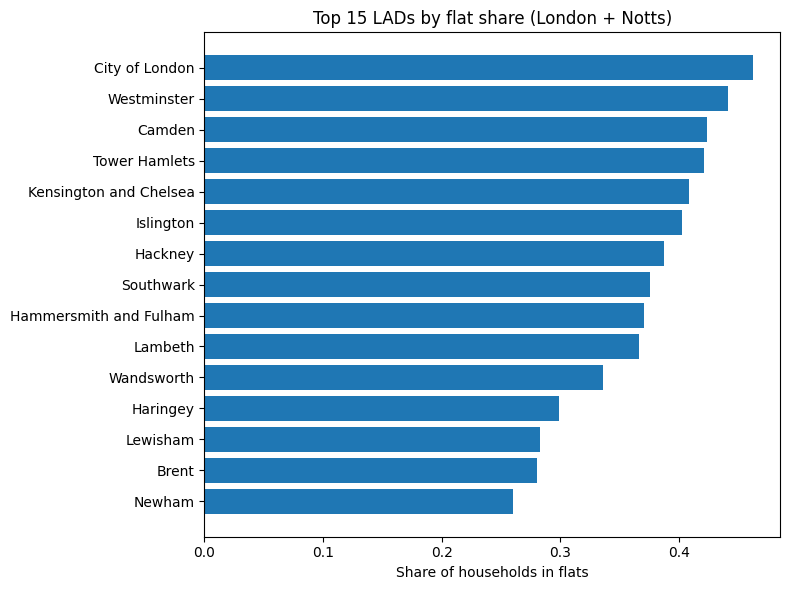

In [2]:
import matplotlib.pyplot as plt
top = housing.sort_values('share_flats', ascending=True).tail(15)
plt.figure(figsize=(8,6))
plt.barh(top['lad_name'], top['share_flats'])
plt.xlabel('Share of households in flats'); plt.title('Top 15 LADs by flat share (London + Notts)')
plt.tight_layout()


## Renting + flat = lower agency to adapt

Text(0.5, 1.0, 'Flat share vs private rented share')

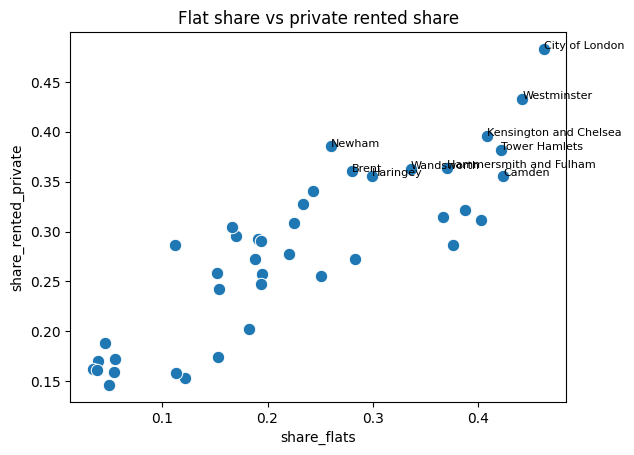

In [3]:
import seaborn as sns
sns.scatterplot(data=housing, x='share_flats', y='share_rented_private', s=80)
for _, r in housing.iterrows():
    if r.share_flats > 0.5 or r.share_rented_private > 0.35:
        plt.text(r.share_flats, r.share_rented_private, r.lad_name, fontsize=8)
plt.title('Flat share vs private rented share')
